# Evaluating the Representation of Fires in Georgia, USA, in the FINN Biomass Burning Emissions Inventory

## Research Questions

RQ1.
How accurately does FINN represent agricultural and prescribed fires in Georgia during June 2022?

RQ2.
To what extent do FINN detections spatially align with EPA-reported fire locations?

RQ3.
How accurately does FINN represent fire based on PM2.5 emissions?

RQ4.
How accurately does FINN represent fire based on burned area?

RQ5.
Is June 2022 representative of FINN performance across the 2022 fire season?

### 1. Setup

In [1]:
import sys
import os

import numpy as np
import geopandas as gpd
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter
from matplotlib import colors
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# from scipy.stats import ttest_ind, ks_2samp
from numba import njit, prange
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import spearmanr
from statsmodels.stats.proportion import proportion_confint
import statsmodels.formula.api as smf

project_root = "/glade/u/home/spatrin"
FIG_DIR = f"{project_root}/final_figures"
os.makedirs(FIG_DIR, exist_ok=True)

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

print("Project root:", project_root)

Project root: /glade/u/home/spatrin


In [2]:
from utils import *
from data_loading import *
from pipeline import *
from spatial_utils import *
from geo_utils import *
from conversion import *
from aggregation import *

In [3]:
FIRE_ORDER = FIRE_TYPES
ACRES_TO_KM2 = 0.00404686

print("Fire type order used throughout:", FIRE_ORDER)

Fire type order used throughout: ['Agricultural', 'Prescribed', 'Wildfire']


In [4]:
sns.set_theme(style="whitegrid", context="paper")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def savefig(fig, name):
    """Save a figure into FIG_DIR using a consistent naming convention."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight", transparent=False)
    return path

In [5]:
cmap = plt.cm.Reds

cmap_trim = mcolors.LinearSegmentedColormap.from_list(
    "Reds_trim",
    cmap(np.linspace(0.3, 1, 256))
)

### 2. Data Loading

In [6]:
epa = load_epa_data()
epa_june = filter_june(epa)

gdf_june = gpd.GeoDataFrame(
    epa_june,
    geometry=gpd.points_from_xy(epa_june["longitude"], epa_june["latitude"]),
    crs="EPSG:4326"
)

print(f"Full-year EPA fires : {len(epa):,}")
print(f"June EPA fires      : {len(epa_june):,}")

Full-year EPA fires : 79,563
June EPA fires      : 2,771


In [7]:
gdf_annual = gpd.GeoDataFrame(
    epa,
    geometry=gpd.points_from_xy(
        epa["longitude"],
        epa["latitude"]
    ),
    crs="EPSG:4326"
)

In [8]:
# --- FINN: June 2022, gridded + converted to tons/day ---
finn_data = load_finn_june_processed()

lat = finn_data["lat"].values
lon = finn_data["lon"].values
pm_tons = finn_data["pm_tons"]     # (time, lat, lon), tons/day
pm_total = finn_data["pm_total"]   # (lat, lon), June total
pm_daily = finn_data["pm_daily"]   # (time,), June daily total

ga_mask = get_georgia_mask(lat, lon)

print("FINN grid shape (time, lat, lon):", pm_tons.shape)
print("Georgia grid cells:", int(np.sum(ga_mask)))

/glade/u/home/spatrin/src/data_loading.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


FINN grid shape (time, lat, lon): (30, 1799, 3600)
Georgia grid cells: 1466


In [9]:
finn_annual = load_finn_annual_processed()

pm_annual_total = finn_annual["pm_total"]
annual_time = finn_annual["time"]

/glade/u/home/spatrin/src/data_loading.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [10]:
pm_tons.sum

<bound method DataArrayAggregations.sum of <xarray.DataArray 'fire_modisviirs_PM25' (time: 30, lat: 1799, lon: 3600)> Size: 777MB
dask.array<mul, shape=(30, 1799, 3600), dtype=float32, chunksize=(1, 600, 1200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2022-06-01 2022-06-02 ... 2022-06-30
  * lat      (lat) float32 7kB -89.95 -89.85 -89.75 -89.65 ... 89.65 89.75 89.85
  * lon      (lon) float32 14kB -180.0 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:      molecules/cm^2/s
    map:        PM25->PM25;aerosol
    long_name:  modisviirs_PM25 fire emissions>

### 3. Methods

In [11]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    n_x = len(x)
    n_y = len(y)

    gt = 0
    lt = 0

    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    return (gt - lt) / (n_x * n_y)

def summarize_skewed(x):
    return pd.Series({
        "N": len(x),
        "Median": np.median(x),
        "Q1": np.percentile(x,25),
        "Q3": np.percentile(x,75),
        "P95": np.percentile(x,95),
        "Total": np.sum(x)
    })

#### 3.1 EPA

**Figure 1.**  EPA point fires and EPA emissions after aggregation to the FINN 0.1° grid.

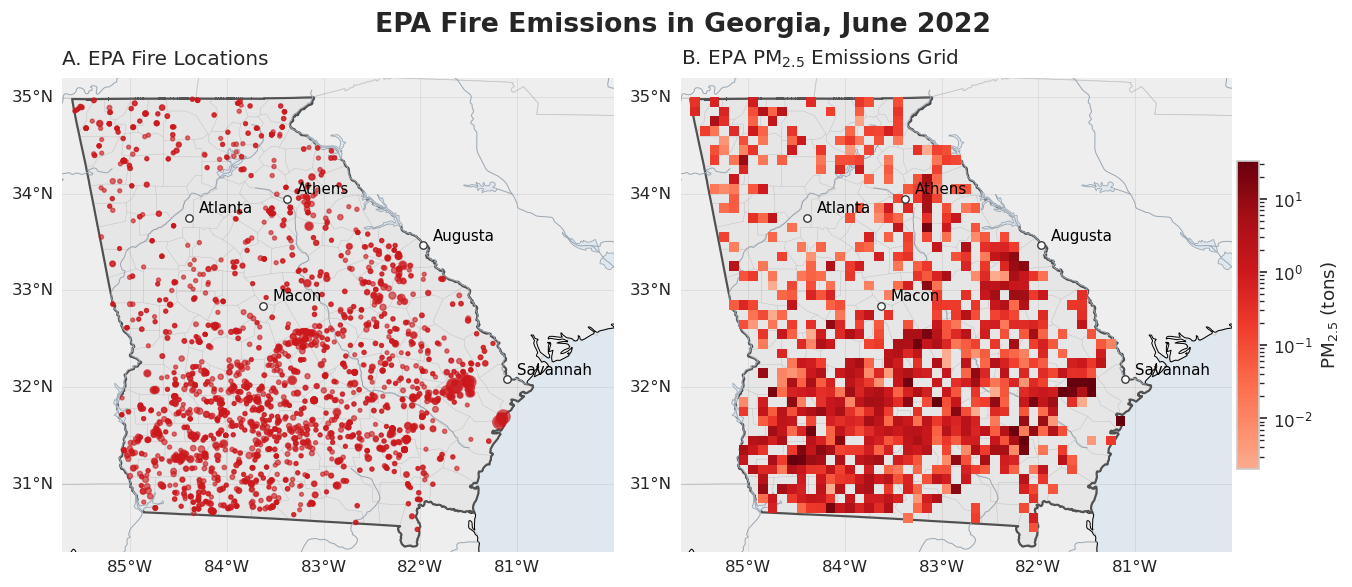

In [12]:
# --- Figure 1: EPA fire locations + gridded PM2.5 emissions ---
epa_grid_pm25 = epa_to_finn_grid(gdf_june, lat, lon, weight_type="pm25")
epa_grid_pm25 = apply_ga_mask(epa_grid_pm25, ga_mask)

plot_grid = epa_grid_pm25.copy()
plot_grid[plot_grid <= 0] = np.nan

cmap_reds = mcolors.LinearSegmentedColormap.from_list(
    "reds_trim", plt.cm.Reds(np.linspace(0.3, 1, 256))
)

vmin = np.nanpercentile(plot_grid, 1)
vmax = np.nanpercentile(plot_grid, 99)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(left=0.05, right=0.9, bottom=0.08, top=0.87, wspace=0.02)

# Panel A: EPA point locations, sized by reported PM2.5
ax = axes[0]
basemap(ax)
vals = gdf_june["pm2.5"].fillna(0).values
vals_sqrt = np.sqrt(vals)
sizes = 5 + (vals_sqrt / (vals_sqrt.max() + 1e-6)) * 80
ax.scatter(
    gdf_june.geometry.x, gdf_june.geometry.y,
    s=sizes, color="#cb181d", alpha=0.6,
    transform=ccrs.PlateCarree(), zorder=4
)
ax.set_title("A. EPA Fire Locations", fontsize=12, pad=8, loc="left")

# Panel B: EPA gridded onto the FINN lattice
ax = axes[1]
basemap(ax)
mesh = ax.pcolormesh(
    lon, lat, plot_grid, cmap=cmap_reds, norm=norm,
    shading="nearest", zorder=4
)
cax = inset_axes(
    axes[1], width="4%", height="65%", loc="center right",
    bbox_to_anchor=(0.05, 0., 1, 1), bbox_transform=axes[1].transAxes, borderpad=0
)
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("PM$_{2.5}$ (tons)", fontsize=11)
cbar.ax.tick_params(labelsize=10)
ax.set_title("B. EPA PM$_{2.5}$ Emissions Grid", fontsize=12, pad=8, loc="left")

fig.suptitle("EPA Fire Emissions in Georgia, June 2022", fontsize=16, fontweight="bold", y=0.98)

savefig(fig, "fig01_epa_pt_grid.png")
plt.show()

In [13]:
epa_annual_summary = (
    epa
    .groupby("type")["pm2.5"]
    .apply(summarize_skewed)
)

display(epa_annual_summary)

type                
Agricultural  N         16704.000000
              Median        0.056271
              Q1            0.020478
              Q3            0.204782
              P95           0.819128
              Total      3259.254103
Prescribed    N         55926.000000
              Median        0.262079
              Q1            0.055368
              Q3            1.332608
              P95           6.265829
              Total     98155.099630
Wildfire      N          6933.000000
              Median        0.038021
              Q1            0.007801
              Q3            0.189272
              P95           1.667189
              Total      4140.379911
Name: pm2.5, dtype: float64

#### 3.2 Detection Classification

In [14]:
def classify_all_days(gdf, finn, lat, lon):
    """Classify every EPA fire in `gdf` as matched/missed using the nearest-day FINN field."""
    results = []
    for date in sorted(gdf["date"].dt.normalize().unique()):
        epa_day = gdf[gdf["date"].dt.normalize() == date]
        if len(epa_day) == 0:
            continue
        finn_day = finn["pm_tons"].sel(time=date, method="nearest").values
        results.append(classify_missed_fires(epa_day, finn_day, lat, lon))
    return pd.concat(results, ignore_index=True)

fire_match_df = classify_all_days(gdf_june, finn_data, lat, lon)
fire_match_df["area_km2"] = fire_match_df["area"] * ACRES_TO_KM2
fire_match_df["Detection Status"] = fire_match_df["matched"].map({1: "Detected", 0: "Missed"})

print(f"Total fires classified : {len(fire_match_df):,}")
print(f"Detected               : {int(fire_match_df['matched'].sum()):,}")
print(f"Missed                 : {int((fire_match_df['matched'] == 0).sum()):,}")

Total fires classified : 2,771
Detected               : 260
Missed                 : 2,511


#### 3.3 Detection Metrics

Discussion:
TP
FN
FP
Precision
Recall
F1
Jaccad
Dice


#### 3.4 Statistical Analyses

- mannwhitneyu  - 
kruska    l- 
cliffs_del     t- a
lo
   git

| Question                          | Test                |
| --------------------------------- | ------------------- |
| June vs annual representativeness | Mann–Whitney U      |
| Fire-type differences             | Kruskal–Wallis      |
| Detection \~ PM2.5                | Logistic regression |
| Detection \~ area                 | Logistic regression |


## 4. Results

### 4.1 EPA Fire Climatology in Georgia During 2022

Fire counts and seasonal trends across all of 2022, before narrowing to the June study perdio.


**Figure 2.** Total EPA fire events by type, full year 2022.

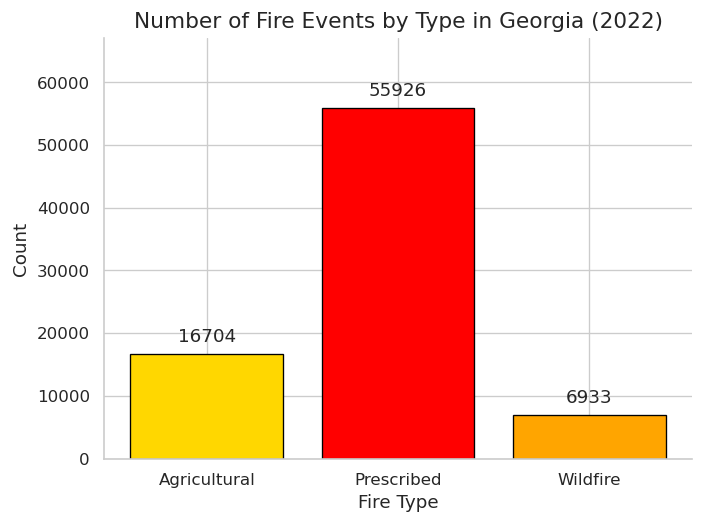

In [15]:
counts_full = epa["type"].value_counts().reindex(FIRE_ORDER)
colors_full = [FIRE_COLORS[t] for t in FIRE_ORDER]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(counts_full.index, counts_full.values, color=colors_full, edgecolor="black")

ax.bar_label(
    ax.containers[0],
    padding=5
)
ax.set_ylim(0, counts_full.max() * 1.2)

ax.set_title("Number of Fire Events by Type in Georgia (2022)")
ax.set_xlabel("Fire Type")
ax.set_ylabel("Count")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig02_fire_counts_2022.png")
plt.show()

**Figure 3.** Monthly fire-count trends by type across 2022 (time series).

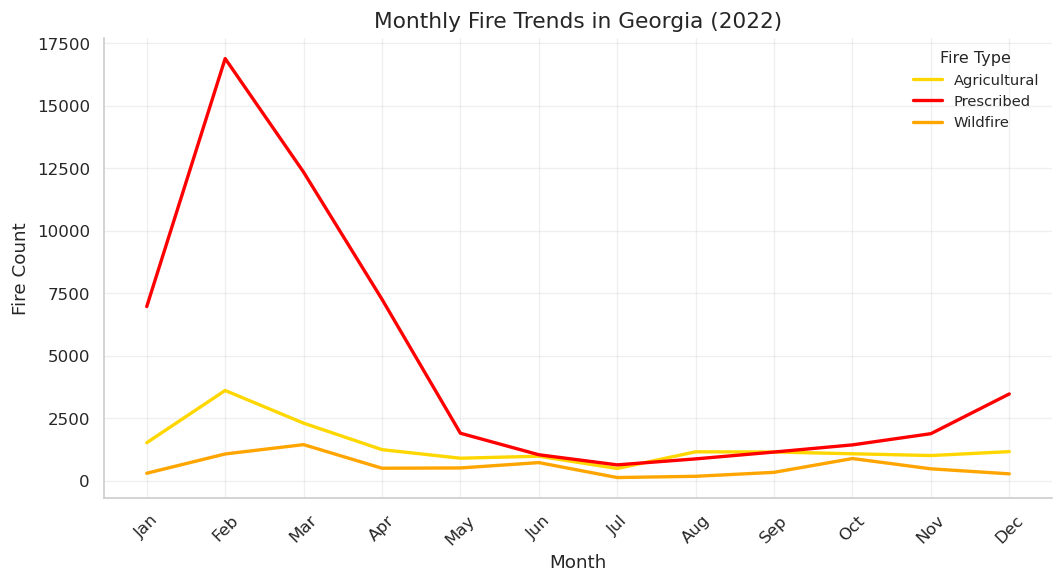

In [16]:
monthly_counts = (
    epa.groupby(["month", "type"]).size().unstack().reindex(columns=FIRE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
for t in FIRE_ORDER:
    ax.plot(monthly_counts.index, monthly_counts[t], label=t, color=FIRE_COLORS[t], linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS_LABELS, rotation=45)

ax.set_title("Monthly Fire Trends in Georgia (2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Fire Count")
ax.grid(alpha=0.3)
ax.legend(title="Fire Type")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig03_monthly_fire_trends.png")
plt.show()

**Figure 4.** Monthly fire emission trends by type across 2022 (time series).

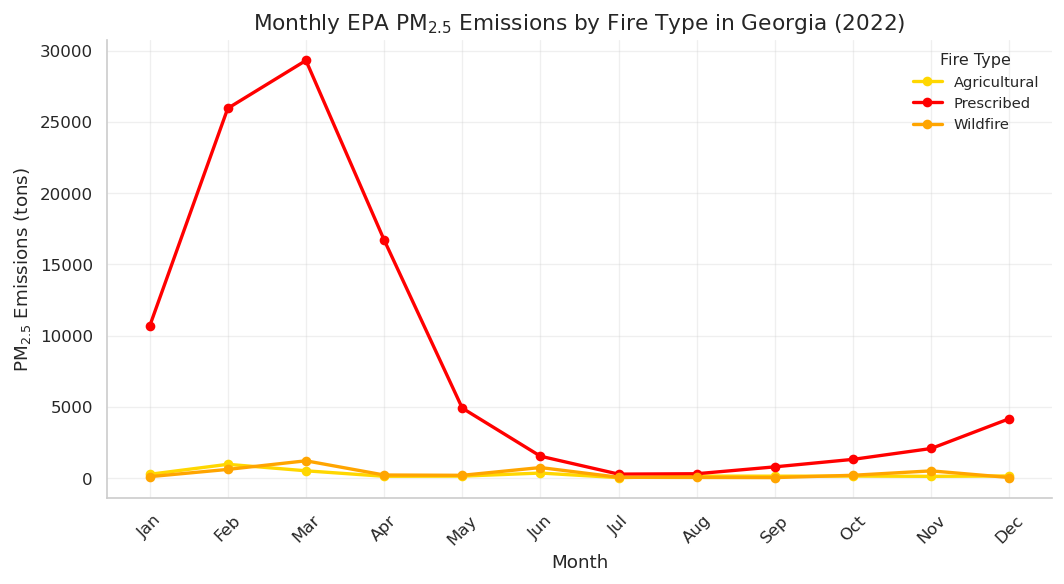

In [17]:
monthly_pm25 = (
    epa.groupby(["month", "type"])["pm2.5"]
       .sum()
       .unstack()
       .reindex(columns=FIRE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))

for t in FIRE_ORDER:
    ax.plot(
        monthly_pm25.index,
        monthly_pm25[t],
        label=t,
        color=FIRE_COLORS[t],
        linewidth=2,
        marker="o"
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS_LABELS, rotation=45)

ax.set_title("Monthly EPA PM$_{2.5}$ Emissions by Fire Type in Georgia (2022)")
ax.set_xlabel("Month")
ax.set_ylabel("PM$_{2.5}$ Emissions (tons)")
ax.legend(title="Fire Type")
ax.grid(alpha=0.3)

sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig04_monthly_pm25_by_type.png")
plt.show()

In [18]:
annual_summary = (
    epa
    .groupby("type")["pm2.5"]
    .apply(summarize_skewed)
)

display(annual_summary)

type                
Agricultural  N         16704.000000
              Median        0.056271
              Q1            0.020478
              Q3            0.204782
              P95           0.819128
              Total      3259.254103
Prescribed    N         55926.000000
              Median        0.262079
              Q1            0.055368
              Q3            1.332608
              P95           6.265829
              Total     98155.099630
Wildfire      N          6933.000000
              Median        0.038021
              Q1            0.007801
              Q3            0.189272
              P95           1.667189
              Total      4140.379911
Name: pm2.5, dtype: float64

In [19]:
#perhaps delete cell?
ag = epa.loc[
    epa.type=="Agricultural",
    "pm2.5"
]

pr = epa.loc[
    epa.type=="Prescribed",
    "pm2.5"
]

wf = epa.loc[
    epa.type=="Wildfire",
    "pm2.5"
]

H,p = kruskal(
    ag,
    pr,
    wf
)

In [20]:
H,p = kruskal(
    ag,
    pr,
    wf
)

print(
    f"Kruskal-Wallis H={H:.2f}, p={p:.3e}"
)

print("\nMedian PM2.5")

for t in FIRE_ORDER:

    vals = epa.loc[
        epa["type"]==t,
        "pm2.5"
    ]

    print(
        f"{t}: {np.median(vals):.2f}"
    )

Kruskal-Wallis H=8112.85, p=0.000e+00

Median PM2.5
Agricultural: 0.06
Prescribed: 0.26
Wildfire: 0.04


### 4.2 Is June Representative of 2022?

**Figure 5.** PM$_{2.5}$ and burned-area distributions (violin + boxplot), split by detection status. Statistical tests below support the annotated $p$-values.

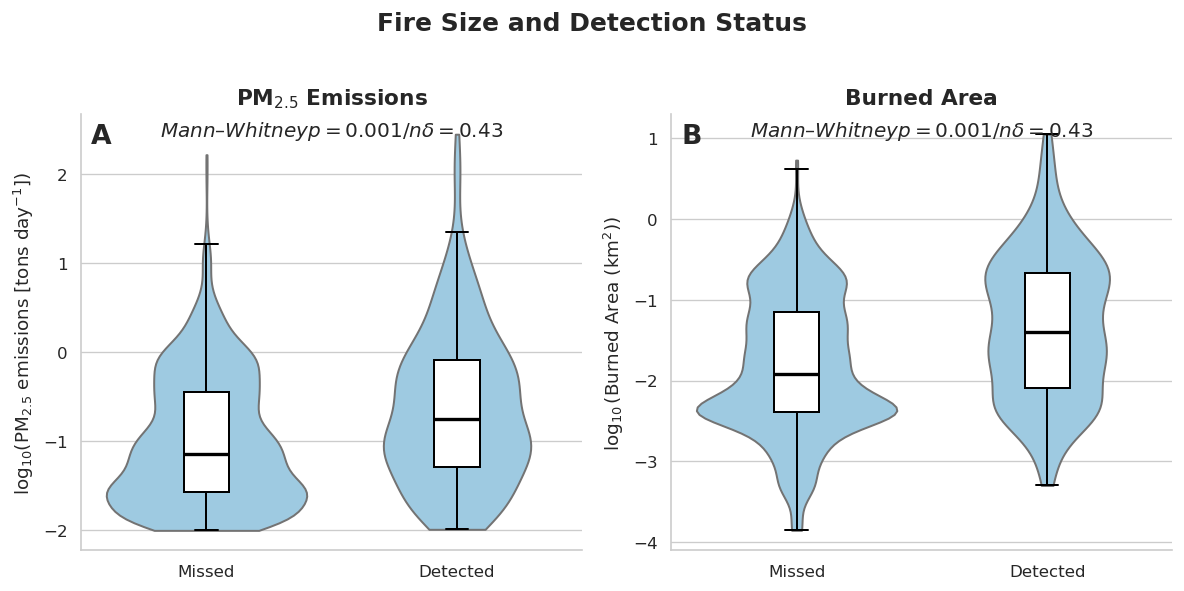

In [21]:
fire_match_df["log_pm25"] = np.log10(fire_match_df["pm2.5"] + 0.01)
fire_match_df["log_area"] = np.log10(fire_match_df["area_km2"] + 1e-4)  # area in km^2

violin_color = "#9ecae1"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))


def violin_panel(ax, df, y_col, ylabel, panel_label, title, log_scale=False):
    sns.violinplot(data=df, x="Detection Status", y=y_col, inner=None,
                   color=violin_color, saturation=1, cut=0, linewidth=1.2, ax=ax)
    sns.boxplot(data=df, x="Detection Status", y=y_col, width=0.18, showcaps=True,
                fliersize=0,
                boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black", linewidth=1.2), ax=ax)
    sample = df.sample(min(800, len(df)), random_state=42)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, fontsize=16,
            fontweight="bold", va="top")
    ax.text(0.5, 0.95, r"$Mann–Whitney p = 0.001 /n δ = 0.43$", transform=ax.transAxes, ha="center", fontsize=12)
    sns.despine(ax=ax)


violin_panel(axes[0], fire_match_df, "log_pm25",
             r"log$_{10}$(PM$_{2.5}$ emissions [tons day$^{-1}$])", "A", r"PM$_{2.5}$ Emissions")

violin_panel(axes[1], fire_match_df, "log_area",
             r"$\log_{10}(\mathrm{Burned\ Area\ (km^2)})$", "B", "Burned Area")

fig.suptitle("Fire Size and Detection Status", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
savefig(fig, "fig05_size_vs_detection_violin.png")
plt.show()

**Figure 6.** Total EPA fire events by type, restricted to June 2022 (the study period).

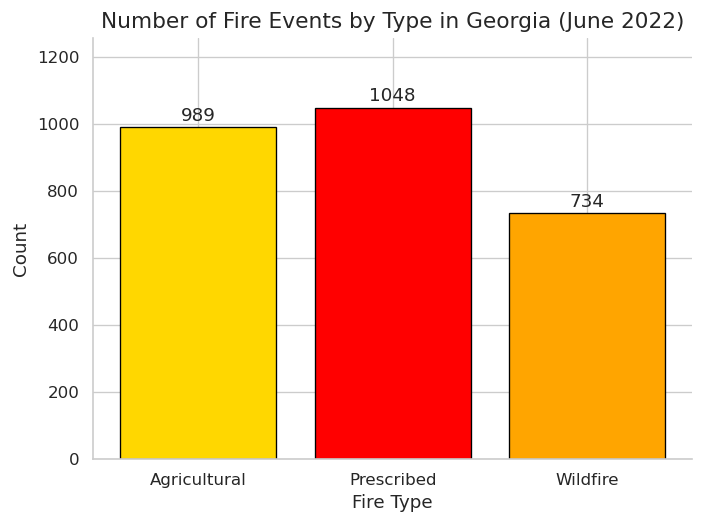

type
Agricultural    35.7
Prescribed      37.8
Wildfire        26.5
Name: percent_of_june_fires, dtype: float64

In [22]:
counts_june = epa_june["type"].value_counts().reindex(FIRE_ORDER)
colors_june = [FIRE_COLORS[t] for t in FIRE_ORDER]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(counts_june.index, counts_june.values, color=colors_june, edgecolor="black")
add_bar_labels(ax, counts_june.values)
ax.set_ylim(0, counts_june.max() * 1.2)
ax.set_title("Number of Fire Events by Type in Georgia (June 2022)")
ax.set_xlabel("Fire Type")
ax.set_ylabel("Count")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig06_fire_counts_june2022.png")
plt.show()

(counts_june / counts_june.sum() * 100).round(1).rename("percent_of_june_fires")

In [23]:
other = epa.loc[
    epa.month != 6,
    "pm2.5"
]

june = epa.loc[
    epa.month == 6,
    "pm2.5"
]

u,p = mannwhitneyu(
    june,
    other,
    alternative="two-sided"
)

delta = cliffs_delta(
    june,
    other
)
print(
    f"MWU p={p:.3e}"
)

print(
    f"Cliff's delta={delta:.3f}"
)

MWU p=1.334e-68
Cliff's delta=-0.195


In [24]:
# June representativeness relative to 2022

annual_pm = epa["pm2.5"].dropna()
june_pm = epa.loc[
    epa["month"] == 6,
    "pm2.5"
].dropna()

summary_compare = pd.DataFrame({
    "Annual": summarize_skewed(annual_pm),
    "June": summarize_skewed(june_pm)
})

display(summary_compare)

,Annual,June
N,79563.000000,2771.000000
Median,0.150497,0.071686
Q1,0.031567,0.017868
Q3,0.806322,0.388321
P95,5.135666,2.214732
Total,105554.733644,2674.693335


In [25]:
u,p = mannwhitneyu(
    june_pm,
    annual_pm,
    alternative="two-sided"
)

delta = cliffs_delta(
    june_pm,
    annual_pm
)

print(
    f"Mann-Whitney U p-value = {p:.3e}"
)

print(
    f"Cliff's Delta = {delta:.3f}"
)

Mann-Whitney U p-value = 4.153e-64
Cliff's Delta = -0.189


### 4.3 FINN Fire Activity During June 2022

In [26]:
pm_plot = apply_ga_mask(pm_total.values, ga_mask)
pm_plot[pm_plot <= 1e-6] = np.nan

In [27]:
annual_grid = np.array(pm_annual_total)

annual_grid = apply_ga_mask(
    annual_grid,
    ga_mask
)

annual_grid[
    annual_grid <= 1e-6
] = np.nan

In [28]:
june_vals = pm_plot[np.isfinite(pm_plot)]
annual_vals = annual_grid[np.isfinite(annual_grid)]

all_vals = np.concatenate([june_vals, annual_vals])

common_vmin = np.nanpercentile(all_vals, 1)
common_vmax = np.nanpercentile(all_vals, 99)

norm = LogNorm(vmin=common_vmin, vmax=common_vmax)

**Figure 7.** Total FINN PM$_{2.5}$ emissions for Georgia, June 2022.

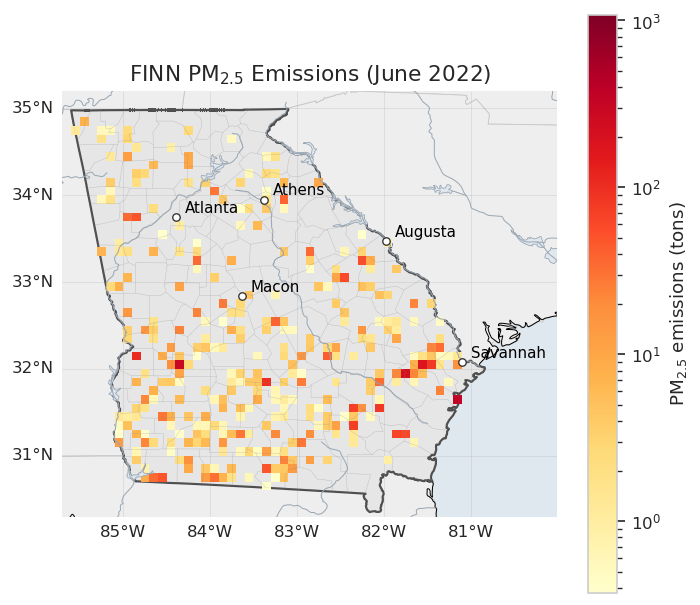

In [29]:
fig, ax = basemap()

mesh = ax.pcolormesh(
    lon, lat, pm_plot, cmap="YlOrRd", norm=norm,
    transform=ccrs.PlateCarree(), shading="nearest", zorder=2
)

cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, extend="neither")
cbar.set_label(r"PM$_{2.5}$ emissions (tons)")

ax.set_title("FINN PM$_{2.5}$ Emissions (June 2022)", fontsize=13)

plt.tight_layout()
savefig(fig, "fig07a_finn_pm25_emissions.png")
plt.show()

***Figure 7B.***
Annual FINN PM2.5 Emissions (2022)

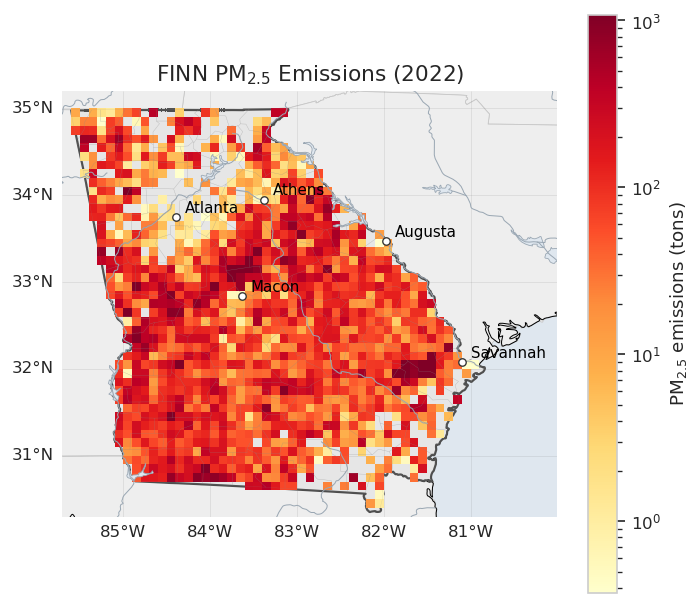

In [30]:
fig, ax = basemap()

mesh = ax.pcolormesh(
    lon, lat, annual_grid, cmap="YlOrRd", norm=norm,
    transform=ccrs.PlateCarree(), shading="nearest", zorder=2
)

cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, extend="neither")
cbar.set_label(r"PM$_{2.5}$ emissions (tons)")

ax.set_title("FINN PM$_{2.5}$ Emissions (2022)", fontsize=13)

plt.tight_layout()
savefig(fig, "fig07b_finn_annual_pm25_emissions.png")
plt.show()

In [31]:
# monthly_finn = (
#     finn_annual["pm_tons"]
#     .sum(dim=["lat","lon"])
#     .groupby("time.month")
#     .sum()
# )
# ga_pm_annual = apply_ga_mask(
#     finn_annual["pm_tons"].values,
#     ga_mask
# )

# monthly_finn = (
#     xr.DataArray(
#         ga_pm_annual,
#         coords=finn_annual["pm_tons"].coords,
#         dims=finn_annual["pm_tons"].dims
#     )
#     .sum(dim=["lat","lon"])
#     .groupby("time.month")
#     .sum()
# )
monthly_finn = (
    finn_annual["pm_daily"]
    .groupby("time.month")
    .sum()
)

***Figure 8*** Monthly PM 2.5 Emissions in Georgia 2022

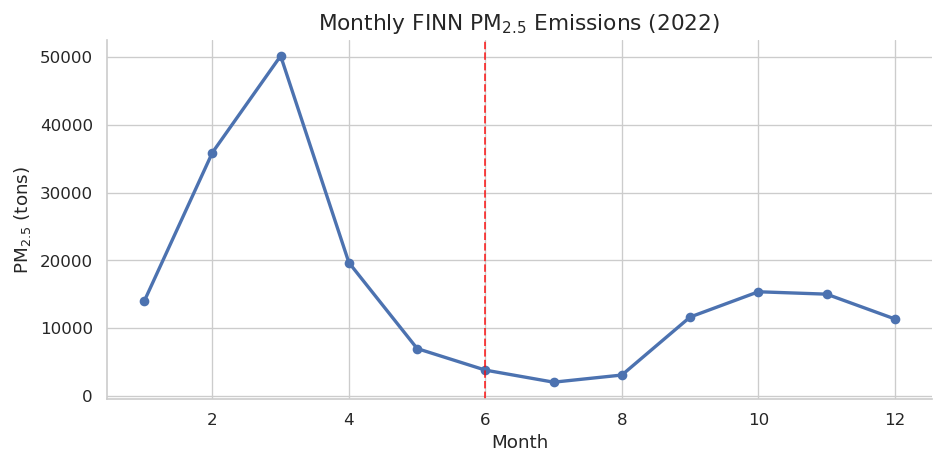

In [32]:
plt.figure(figsize=(8,4))

plt.plot(
    monthly_finn["month"],
    monthly_finn,
    marker="o",
    linewidth=2
)

plt.axvline(
    6,
    ls="--",
    color="red",
    alpha=0.7
)

plt.title(
    "Monthly FINN PM$_{2.5}$ Emissions (2022)"
)

plt.ylabel("PM$_{2.5}$ (tons)")
plt.xlabel("Month")

plt.tight_layout()
savefig(fig, "fig08_finn_monthly_pm25_emissions.png")
plt.show()

### 4.4 Spatial Agreement Between EPA and FINN

In [33]:
# --- grid edges & per-day FINN/EPA lookups for the spatial miss-rate maps ---
dlat = lat[1] - lat[0]
dlon = lon[1] - lon[0]
lat_edges = np.concatenate([[lat[0] - dlat / 2], lat + dlat / 2])
lon_edges = np.concatenate([[lon[0] - dlon / 2], lon + dlon / 2])

epa_dates = pd.to_datetime(gdf_june["date"]).dt.floor("D").values
epa_lat_pts = gdf_june.geometry.y.values
epa_lon_pts = gdf_june.geometry.x.values
epa_type_pts = gdf_june["type"].values

unique_dates, inverse_idx = np.unique(epa_dates, return_inverse=True)
date_groups = [np.where(inverse_idx == i)[0] for i in range(len(unique_dates))]

finn_times = pd.to_datetime(finn_data["time"].values).floor("D").values
time_lookup = np.array([np.argmin(np.abs(finn_times - d)) for d in unique_dates])

ga_mask_bool = ga_mask.astype(np.bool_)
nlat, nlon = len(lat), len(lon)


@njit(parallel=True)
def _apply_mask_fast(grid, mask):
    for i in prange(grid.shape[0]):
        for j in range(grid.shape[1]):
            if not mask[i, j]:
                grid[i, j] = np.nan
    return grid


@njit
def _compute_miss_fast(epa_grid, finn_grid, threshold=1e-3):
    miss = np.zeros_like(epa_grid)
    for i in range(epa_grid.shape[0]):
        for j in range(epa_grid.shape[1]):
            if epa_grid[i, j] > 0 and finn_grid[i, j] <= threshold:
                miss[i, j] = 1
    return miss

In [34]:
miss_ag = np.zeros((nlat, nlon))
miss_prescribed = np.zeros((nlat, nlon))
miss_wildfire = np.zeros((nlat, nlon))
miss_total = np.zeros((nlat, nlon))

for i in range(len(unique_dates)):
    inds = date_groups[i]
    if len(inds) == 0:
        continue

    lat_pts, lon_pts, types = epa_lat_pts[inds], epa_lon_pts[inds], epa_type_pts[inds]

    epa_grid, _, _ = np.histogram2d(lat_pts, lon_pts, bins=[lat_edges, lon_edges])
    epa_grid = _apply_mask_fast(epa_grid, ga_mask_bool)

    finn_grid = pm_tons.isel(time=time_lookup[i]).values.copy()
    finn_grid = _apply_mask_fast(finn_grid, ga_mask_bool)

    miss = _compute_miss_fast(epa_grid, finn_grid)

    for type_name, target in [
        ("Agricultural", miss_ag),
        ("Prescribed", miss_prescribed),
        ("Wildfire", miss_wildfire),
    ]:
        type_mask = types == type_name
        if np.any(type_mask):
            type_grid, _, _ = np.histogram2d(
                lat_pts[type_mask], lon_pts[type_mask], bins=[lat_edges, lon_edges]
            )
            target += (type_grid > 0) * miss

    miss_total += miss

for grid in (miss_ag, miss_prescribed, miss_wildfire, miss_total):
    grid[grid == 0] = np.nan

print("Total missed grid-days:", np.nansum(miss_total))
print("  Agricultural:", np.nansum(miss_ag))
print("  Prescribed  :", np.nansum(miss_prescribed))
print("  Wildfire    :", np.nansum(miss_wildfire))

Total missed grid-days: 1623.0
  Agricultural: 848.0
  Prescribed  : 468.0
  Wildfire    : 343.0


***Figure 9*** Spatial distribution of missed EPA fires (grid-cell counts, summed over June), overall and split by fire type

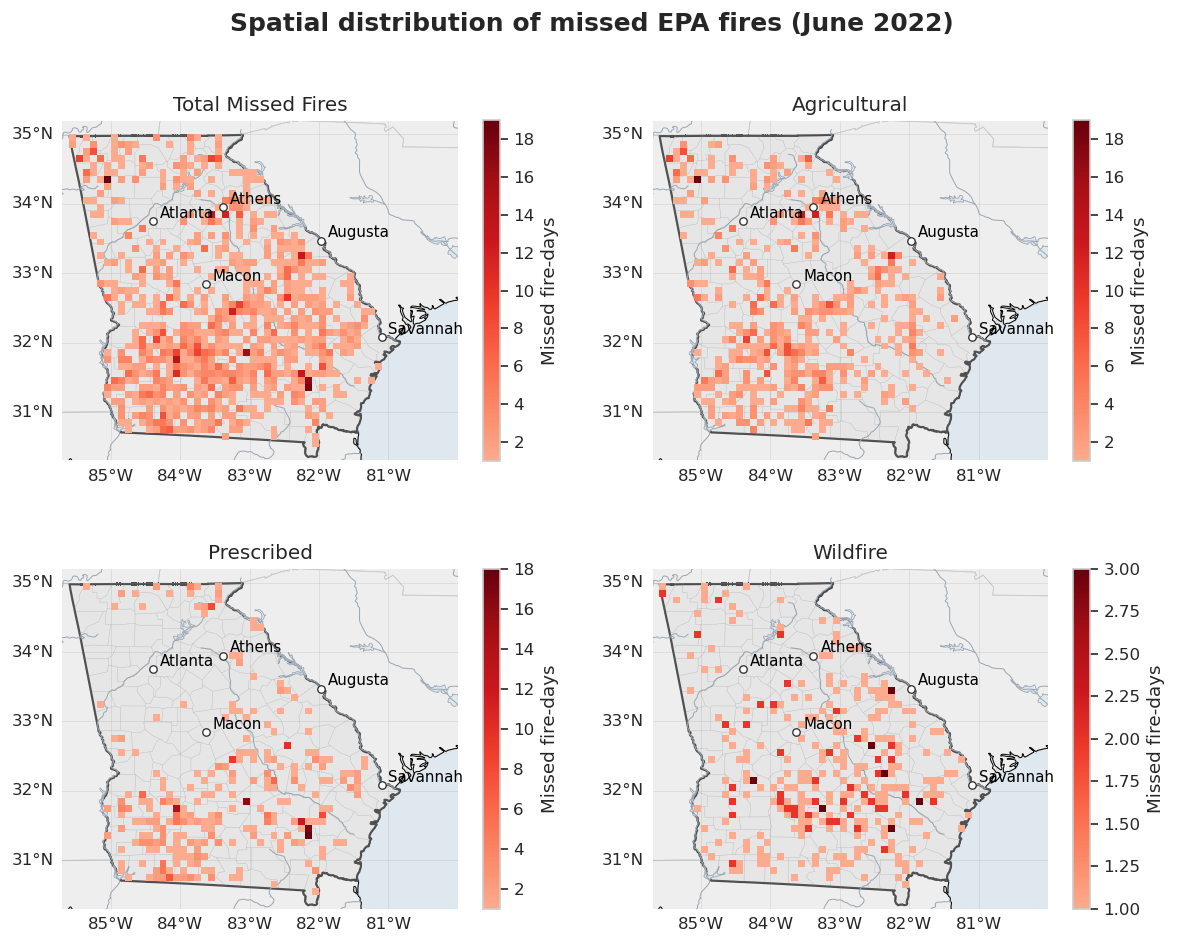

In [35]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

panels = [
    ("Total Missed Fires", miss_total),
    ("Agricultural", miss_ag),
    ("Prescribed", miss_prescribed),
    ("Wildfire", miss_wildfire),
]

for ax, (title, grid) in zip(axes.ravel(), panels):
    basemap(ax)
    mesh = ax.pcolormesh(
        lon, lat, grid, transform=ccrs.PlateCarree(),
        shading="nearest", cmap=cmap_trim, zorder=5
    )
    ax.set_title(title, fontsize=12)
    plt.colorbar(mesh, ax=ax, shrink=0.8, label="Missed fire-days")

fig.suptitle("Spatial distribution of missed EPA fires (June 2022)", fontsize=15, fontweight="bold", y=1.0)

plt.tight_layout()
savefig(fig, "fig09_miss_rate_by_type_maps.png")
plt.show()

#### Spatiotemporal Correlation

In [36]:
daily_spatial_corr = []

for date in sorted(
    pd.to_datetime(
        gdf_june["date"]
    ).dt.normalize().unique()
):

    epa_day = get_daily_epa(
        gdf_june,
        date
    )

    epa_grid = epa_to_finn_grid(
        epa_day,
        lat,
        lon,
        "pm25"
    )

    epa_grid = apply_ga_mask(
        epa_grid,
        ga_mask
    )

    finn_day = (
        finn_data["pm_tons"]
        .sel(
            time=date,
            method="nearest"
        )
        .values
    )

    finn_day = apply_ga_mask(
        finn_day,
        ga_mask
    )

    r = spatial_correlation(
        epa_grid,
        finn_day
    )

    daily_spatial_corr.append({
        "date": date,
        "corr": r
    })

daily_spatial_corr = pd.DataFrame(
    daily_spatial_corr
)

In [37]:
daily_spatial_corr["corr"].describe(
    percentiles=[.25,.5,.75,.95]
)

count    15.000000
mean      0.220475
std       0.428437
min      -0.418055
25%      -0.129785
50%       0.230402
75%       0.610104
95%       0.750954
max       0.825618
Name: corr, dtype: float64

In [38]:
median_corr = daily_spatial_corr["corr"].median()
mean_corr = daily_spatial_corr["corr"].mean()

print(f"Mean correlation: {mean_corr:.3f}")
print(f"Median correlation: {median_corr:.3f}")

Mean correlation: 0.220
Median correlation: 0.230


In [39]:
positive_days = (
    daily_spatial_corr["corr"] > 0
).mean() * 100

print(
    f"Days with positive spatial correlation: "
    f"{positive_days:.1f}%"
)

Days with positive spatial correlation: 33.3%


***Figure 10.*** Daily EPA–FINN Spatiotemporal Correlation

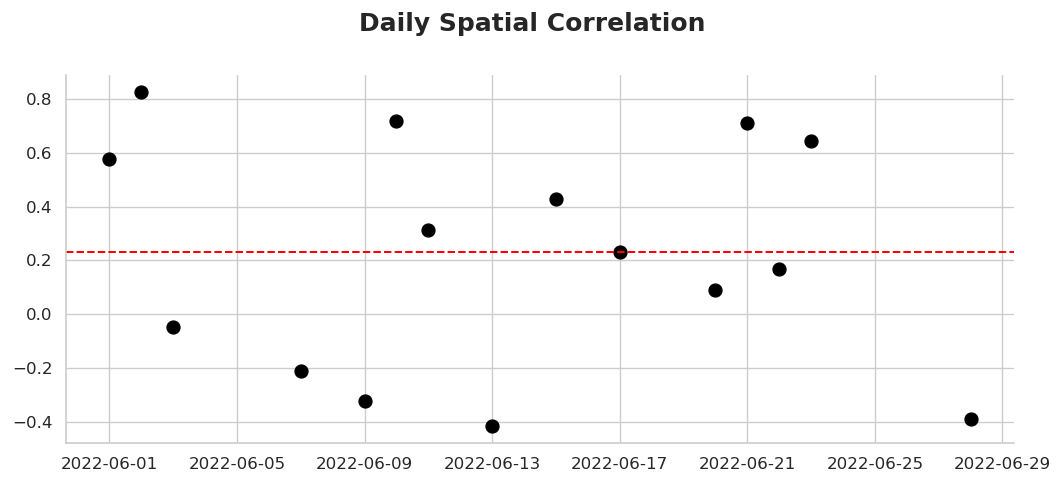

In [40]:
fig, ax = plt.subplots(
    figsize=(9,4)
)

ax.scatter(
    daily_spatial_corr["date"],
    daily_spatial_corr["corr"],
    s=60,
    color="black"
)

ax.axhline(
    daily_spatial_corr["corr"].median(),
    color="red",
    linestyle="--"
)
fig.suptitle("Daily Spatial Correlation", fontsize=15, fontweight="bold", y=1.0)

plt.tight_layout()
savefig(fig, "fig10_daily_spatial_corr.png")
plt.show()

In [41]:
all_epa = []
all_finn = []

for date in sorted(
    pd.to_datetime(
        gdf_june["date"]
    ).dt.normalize().unique()
):

    epa_day = get_daily_epa(
        gdf_june,
        date
    )

    epa_grid = epa_to_finn_grid(
        epa_day,
        lat,
        lon,
        "pm25"
    )

    epa_grid = apply_ga_mask(
        epa_grid,
        ga_mask
    )

    finn_day = (
        finn_data["pm_tons"]
        .sel(
            time=date,
            method="nearest"
        )
        .values
    )

    finn_day = apply_ga_mask(
        finn_day,
        ga_mask
    )

    valid = (
        np.isfinite(epa_grid)
        & np.isfinite(finn_day)
    )

    all_epa.extend(
        epa_grid[valid].ravel()
    )

    all_finn.extend(
        finn_day[valid].ravel()
    )

all_epa = np.array(all_epa)
all_finn = np.array(all_finn)

bias = np.mean(
    all_finn - all_epa
)

rmse = np.sqrt(
    np.mean(
        (all_finn - all_epa) ** 2
    )
)

print("Bias:", bias)
print("RMSE:", rmse)

Bias: 0.02490922210615998
RMSE: 3.8767006879992056


### 4.5 Detection Performance

#### Detection performance: confusion matrix

**Table 1.** Daily spatiotemporal detection metrics (grid-cell TP/FN/FP, using `run_daily_spatiotemporal_analysis`) by fire type, with a combined total row.

In [42]:
overall_metrics = run_daily_spatiotemporal_analysis(gdf_june, finn_data, lat, lon)

rows = []
for fire_type in FIRE_ORDER:
    subset = gdf_june[gdf_june["type"] == fire_type]
    m = run_daily_spatiotemporal_analysis(subset, finn_data, lat, lon)
    rows.append({
        "Fire Type": fire_type,
        "TP": m["TP"], "FN": m["FN"], "FP": m["FP"],
        "N": m["TP"] + m["FN"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "Miss Rate": m["FN"] / (m["TP"] + m["FN"] + 1e-6),
    })

rows.append({
    "Fire Type": "Total (Combined)",
    "TP": overall_metrics["TP"], "FN": overall_metrics["FN"], "FP": overall_metrics["FP"],
    "N": overall_metrics["TP"] + overall_metrics["FN"],
    "Precision": overall_metrics["precision"],
    "Recall": overall_metrics["recall"],
    "Miss Rate": overall_metrics["FN"] / (overall_metrics["TP"] + overall_metrics["FN"] + 1e-6),
})

confusion_summary = pd.DataFrame(rows).set_index("Fire Type")
confusion_summary[["Precision", "Recall", "Miss Rate"]] = (
    confusion_summary[["Precision", "Recall", "Miss Rate"]].round(3)
)
confusion_summary

,TP,FN,FP,N,Precision,Recall,Miss Rate
Fire Type,,,,,,,
Agricultural,67,848,452,915,0.129,0.073,0.927
Prescribed,57,468,462,525,0.110,0.109,0.891
Wildfire,27,343,492,370,0.052,0.073,0.927
Total (Combined),139,1623,380,1762,0.268,0.079,0.921


#### Detection by fire types.s.

In [43]:
type_detection = (
    fire_match_df
    .groupby("type")["matched"]
    .agg(
        matches="sum",
        count="count"
    )
    .reindex(FIRE_ORDER)
)

type_detection["rate"] = (
    type_detection["matches"]
    /
    type_detection["count"]
)

ci_low = []
ci_high = []

for k, n in zip(
    type_detection["matches"],
    type_detection["count"]
):

    low, high = proportion_confint(
        count=k,
        nobs=n,
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

type_detection["ci_low"] = ci_low
type_detection["ci_high"] = ci_high

display(type_detection)

,matches,count,rate,ci_low,ci_high
type,,,,,
Agricultural,78,989,0.078868,0.063652,0.097342
Prescribed,131,1048,0.125000,0.106336,0.146403
Wildfire,51,734,0.069482,0.053240,0.090207


*** Figure 11 ***
Fraction of EPA fires matched to FINN emissions by fire type.
Bars show the proportion of EPA fire records that were associated with at
least one FINN PM2.5-emitting grid cell during June 2022. Error bars
indicate 95% confidence intervals.

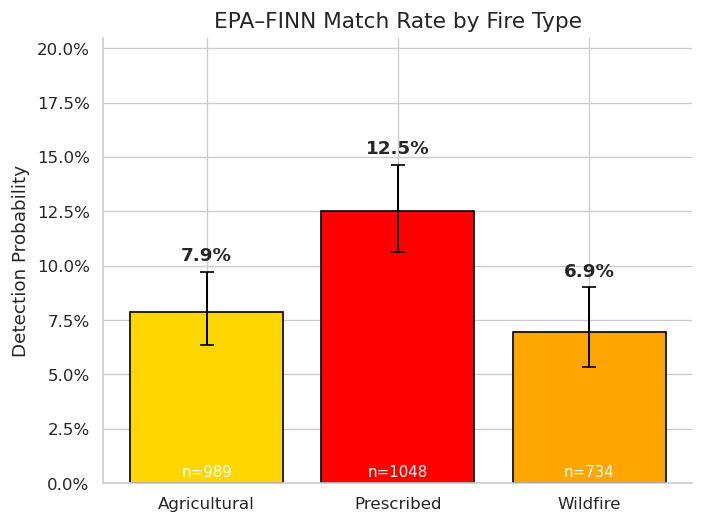

In [44]:
fig, ax = plt.subplots(
    figsize=(6,4.5)
)

bars = ax.bar(
    type_detection.index,
    type_detection["rate"],
    color=[
        FIRE_COLORS[t]
        for t in type_detection.index
    ],
    edgecolor="black",
    linewidth=1
)

lower = (
    type_detection["rate"]
    -
    type_detection["ci_low"]
)

upper = (
    type_detection["ci_high"]
    -
    type_detection["rate"]
)

ax.errorbar(
    np.arange(len(type_detection)),
    type_detection["rate"],
    yerr=[lower, upper],
    fmt="none",
    color="black",
    capsize=4
)

for i, (
    rate,
    n,
    upper_ci
) in enumerate(zip(
    type_detection["rate"],
    type_detection["count"],
    type_detection["ci_high"]
)):

    ax.text(
        i,
        upper_ci + 0.005,
        f"{rate:.1%}",
        ha="center",
        fontweight="bold"
    )

    ax.text(
        i,
        0.003,
        f"n={n}",
        ha="center",
        fontsize=9,
        color="white"
    )

ax.set_ylabel(
    "Detection Probability"
)

ax.set_title(
    "EPA–FINN Match Rate by Fire Type"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_ylim(
    0,
    type_detection["ci_high"].max()
    * 1.4
)

sns.despine()

plt.tight_layout()

savefig(
    fig,
    "fig011_detection_wilson.png"
)

plt.show()

### 4.6 Influence of Fire Size on Detection

***Figure 12**.* EPA–FINN match rates by fire-size quartile. Bars show the fraction of EPA fire records matched to FINN emissions, grouped by quartiles of reported PM₂.₅ emissions (A) and burned area (B). Error bars denote 95% Wilson confidence intervals for binomial proportions. Sample sizes are shown within bars. Match rates increase monotonically with both emissions and burned area, indicating that larger fires are more likely to be represented in the FINN inventory.

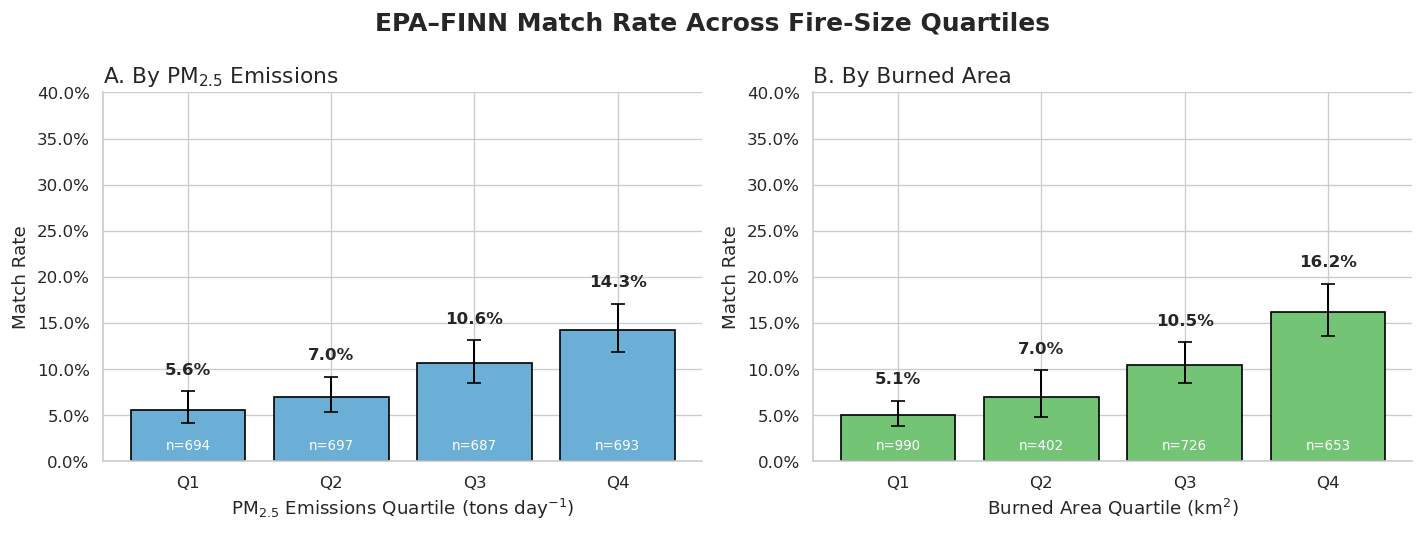

In [45]:
fire_match_df["pm_bin"] = pd.qcut(
    fire_match_df["pm2.5"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

fire_match_df["area_bin"] = pd.qcut(
    fire_match_df["area_km2"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

def match_rate_summary(df, group_col):

    summary = (
        df.groupby(group_col, observed=True)["matched"]
        .agg(matches="sum", count="count")
        .reset_index()
    )

    summary["rate"] = summary["matches"] / summary["count"]

    ci_low = []
    ci_high = []

    for k, n in zip(summary["matches"], summary["count"]):

        low, high = proportion_confint(
            count=k,
            nobs=n,
            alpha=0.05,
            method="wilson"
        )

        ci_low.append(low)
        ci_high.append(high)

    summary["ci_low"] = ci_low
    summary["ci_high"] = ci_high

    return summary


pm_summary = match_rate_summary(fire_match_df, "pm_bin")
area_summary = match_rate_summary(fire_match_df, "area_bin")

pm_edges = fire_match_df["pm2.5"].quantile([0, .25, .5, .75, 1]).values
area_edges = fire_match_df["area_km2"].quantile([0, .25, .5, .75, 1]).values

pm_xticklabels = ["Q1", "Q2", "Q3", "Q4"]
area_xticklabels = ["Q1", "Q2", "Q3", "Q4"]

def plot_match_rate(ax, summary, xticklabels, xlabel, color):

    x = np.arange(len(summary))

    bars = ax.bar(
        x,
        summary["rate"],
        color=color,
        edgecolor="black",
        linewidth=1
    )

    lower = summary["rate"] - summary["ci_low"]
    upper = summary["ci_high"] - summary["rate"]

    ax.errorbar(
        x,
        summary["rate"],
        yerr=[lower, upper],
        fmt="none",
        color="black",
        capsize=4,
        lw=1.2
    )

    for xx, rate, hi, n in zip(
        x,
        summary["rate"],
        summary["ci_high"],
        summary["count"]
    ):

        ax.text(
            xx,
            hi + 0.015,
            f"{rate:.1%}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

        ax.text(
            xx,
            0.01,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Match Rate")

    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 0.40)

    sns.despine(ax=ax)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_match_rate(
    axes[0],
    pm_summary,
    pm_xticklabels,
    r"PM$_{2.5}$ Emissions Quartile (tons day$^{-1}$)",
    "#6baed6"
)
axes[0].set_title("A. By PM$_{2.5}$ Emissions", loc="left")

plot_match_rate(
    axes[1],
    area_summary,
    area_xticklabels,
    r"Burned Area Quartile (km$^2$)",
    "#74c476"
)
axes[1].set_title("B. By Burned Area", loc="left")

fig.suptitle(
    "EPA–FINN Match Rate Across Fire-Size Quartiles",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

savefig(fig, "fig12_match_rate_by_size_quartiles.png")
plt.show()

In [46]:
fire_match_df["log_pm"] = np.log10(fire_match_df["pm2.5"] + 1e-6)
fire_match_df["log_area"] = np.log10(fire_match_df["area_km2"] + 1e-6)

Logistic regression: PM2.5.

In [47]:
pm_model_log = smf.logit(
    "matched ~ log_pm",
    data=fire_match_df
).fit()

print(pm_model_log.summary())

Optimization terminated successfully.
         Current function value: 0.302317
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                matched   No. Observations:                 2771
Model:                          Logit   Df Residuals:                     2769
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                 0.02888
Time:                        11:55:07   Log-Likelihood:                -837.72
converged:                       True   LL-Null:                       -862.64
Covariance Type:            nonrobust   LLR p-value:                 1.677e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8010      0.086    -20.956      0.000      -1.969      -1.633
log_pm         0.4859      0.

Logistic regression: area.

In [48]:
area_model_log = smf.logit(
    "matched ~ log_area",
    data=fire_match_df
).fit()

print(area_model_log.summary())

Optimization terminated successfully.
         Current function value: 0.297818
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                matched   No. Observations:                 2771
Model:                          Logit   Df Residuals:                     2769
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                 0.04333
Time:                        11:55:07   Log-Likelihood:                -825.25
converged:                       True   LL-Null:                       -862.64
Covariance Type:            nonrobust   LLR p-value:                 5.315e-18
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2464      0.125     -9.952      0.000      -1.492      -1.001
log_area       0.6444      0.

In [49]:
logistic_summary = pd.DataFrame({

    "Predictor":[
        "PM2.5",
        "Burned Area"
    ],

    "Odds Ratio":[
        np.exp(pm_model_log.params.iloc[1]),
        np.exp(area_model_log.params.iloc[1])
    ],

    "Pseudo R²":[
        pm_model_log.prsquared,
        area_model_log.prsquared
    ],

    "p-value":[
        pm_model_log.pvalues.iloc[1],
        area_model_log.pvalues.iloc[1]
    ]
})

display(
    logistic_summary.round(3)
)

,Predictor,Odds Ratio,Pseudo R²,p-value
0,PM2.5,1.626,0.029,0.0
1,Burned Area,1.905,0.043,0.0


### 4.7 Emissions and Burned Area Captured by FINN

**Table 2.** Total, detected, and missed PM$_{2.5}$ emissions and burned area by fire type, with a combined total row — and the EPA vs. FINN total-emissions comparison referenced in the discussion.

In [50]:
def emissions_by_type(df):
    total = df.groupby("type").agg(
        total_pm25=("pm2.5", "sum"),
        total_area_km2=("area_km2", "sum"),
    )
    detected = df[df["matched"] == 1].groupby("type").agg(
        detected_pm25=("pm2.5", "sum"), detected_area_km2=("area_km2", "sum")
    )
    missed = df[df["matched"] == 0].groupby("type").agg(
        missed_pm25=("pm2.5", "sum"), missed_area_km2=("area_km2", "sum")
    )
    out = total.join(detected).join(missed).fillna(0)
    out["pct_missed_pm25"] = out["missed_pm25"] / out["total_pm25"] * 100
    out["pct_missed_area"] = out["missed_area_km2"] / out["total_area_km2"] * 100
    return out


emissions_table = emissions_by_type(fire_match_df).reindex(FIRE_ORDER)

total_row = pd.DataFrame({
    "total_pm25": [emissions_table["total_pm25"].sum()],
    "total_area_km2": [emissions_table["total_area_km2"].sum()],
    "detected_pm25": [emissions_table["detected_pm25"].sum()],
    "detected_area_km2": [emissions_table["detected_area_km2"].sum()],
    "missed_pm25": [emissions_table["missed_pm25"].sum()],
    "missed_area_km2": [emissions_table["missed_area_km2"].sum()],
}, index=["Total (Combined)"])
total_row["pct_missed_pm25"] = total_row["missed_pm25"] / total_row["total_pm25"] * 100
total_row["pct_missed_area"] = total_row["missed_area_km2"] / total_row["total_area_km2"] * 100

emissions_table = pd.concat([emissions_table, total_row])
emissions_table.round(2)

,total_pm25,total_area_km2,detected_pm25,detected_area_km2,missed_pm25,missed_area_km2,pct_missed_pm25,pct_missed_area
Agricultural,369.00,112.13,48.09,15.60,320.91,96.53,86.97,86.09
Prescribed,1550.95,167.18,766.80,71.92,784.15,95.26,50.56,56.98
Wildfire,754.74,39.74,50.40,3.36,704.35,36.38,93.32,91.54
Total (Combined),2674.69,319.04,865.28,90.88,1809.41,228.16,67.65,71.51


#### PM 2.5 Capture

In [51]:
# fire classification
annual_fire_match_df = classify_all_days(
    gdf_annual,
    finn_annual,
    lat,
    lon
)

annual_fire_match_df["area_km2"] = (
    annual_fire_match_df["area"]
    *
    ACRES_TO_KM2
)

annual_fire_match_df["Detection Status"] = (
    annual_fire_match_df["matched"]
    .map({
        1:"Detected",
        0:"Missed"
    })
)

print(
    f"Annual fires: {len(annual_fire_match_df):,}"
)

Annual fires: 79,563


In [52]:
pm_capture = (
    annual_fire_match_df
    .groupby("type")
    .apply(
        lambda x: pd.Series({

            "Total PM25":
            x["pm2.5"].sum(),

            "Detected PM25":
            x.loc[
                x["matched"] == 1,
                "pm2.5"
            ].sum()

        })
    )
)

/glade/derecho/scratch/spatrin/tmp/ipykernel_45795/1080852446.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [53]:
pm_capture[
    "Capture Rate"
] = (
    pm_capture["Detected PM25"]
    /
    pm_capture["Total PM25"]
)

pm_capture = (
    pm_capture
    .reindex(FIRE_ORDER)
)

pm_capture

,Total PM25,Detected PM25,Capture Rate
type,,,
Agricultural,3259.254103,660.275800,0.202585
Prescribed,98155.099630,53671.933028,0.546807
Wildfire,4140.379911,1403.884049,0.339071


*** Figure 13. *** PM2.5 capture by fire type.

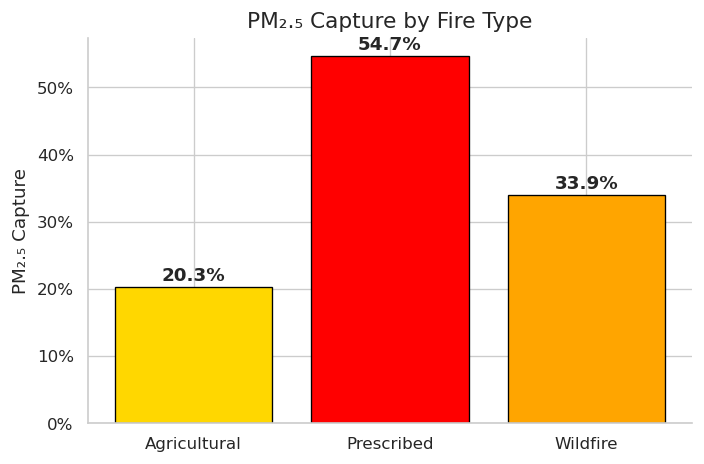

In [54]:
fig, ax = plt.subplots(
    figsize=(6,4)
)

bars = ax.bar(
    pm_capture.index,
    pm_capture["Capture Rate"],
    color=[
        FIRE_COLORS[t]
        for t
        in pm_capture.index
    ],
    edgecolor="black"
)

for bar, value in zip(
    bars,
    pm_capture["Capture Rate"]
):

    ax.text(
        bar.get_x()
        +
        bar.get_width()/2,
        value+0.01,
        f"{value:.1%}",
        ha="center",
        fontweight="bold"
    )

ax.set_ylabel(
    "PM₂.₅ Capture"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_title(
    "PM₂.₅ Capture by Fire Type"
)

plt.tight_layout()

plt.show()

#### Burned Area Capture

In [55]:
area_capture = (
    annual_fire_match_df
    .groupby("type")
    .apply(
        lambda x: pd.Series({

            "Total Area":
            x["area_km2"].sum(),

            "Detected Area":
            x.loc[
                x["matched"] == 1,
                "area_km2"
            ].sum()

        })
    )
)

/glade/derecho/scratch/spatrin/tmp/ipykernel_45795/637606191.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [56]:
area_capture[
    "Capture Rate"
] = (
    area_capture["Detected Area"]
    /
    area_capture["Total Area"]
)

area_capture = (
    area_capture
    .reindex(FIRE_ORDER)
)

area_capture

,Total Area,Detected Area,Capture Rate
type,,,
Agricultural,814.627299,168.010856,0.206243
Prescribed,10209.471124,5388.160117,0.527761
Wildfire,251.385737,86.698544,0.344883


*** Figure 14 *** Burned-area capture by fire type.

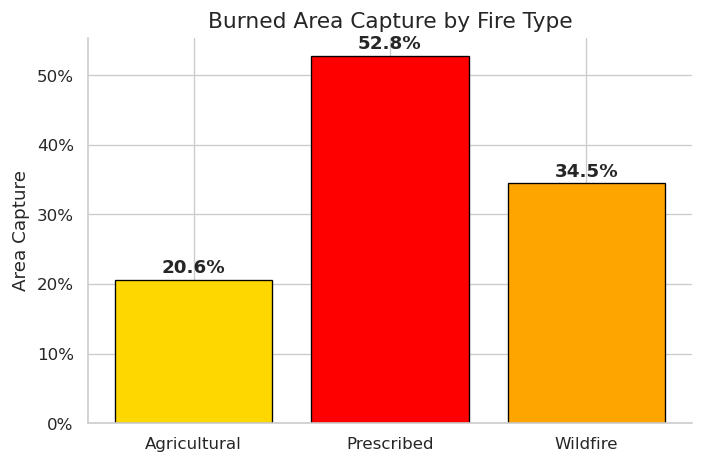

In [57]:
fig, ax = plt.subplots(
    figsize=(6,4)
)

bars = ax.bar(
    area_capture.index,
    area_capture["Capture Rate"],
    color=[
        FIRE_COLORS[t]
        for t
        in area_capture.index
    ],
    edgecolor="black"
)

for bar, value in zip(
    bars,
    area_capture["Capture Rate"]
):

    ax.text(
        bar.get_x()
        +
        bar.get_width()/2,
        value+0.01,
        f"{value:.1%}",
        ha="center",
        fontweight="bold"
    )

ax.set_ylabel(
    "Area Capture"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_title(
    "Burned Area Capture by Fire Type"
)

plt.tight_layout()

plt.show()

### 4.8 June Versus Annual Detection Skill

In [58]:
monthly_skill = []

for month in range(1,13):

    gdf_month = gdf_annual[
        gdf_annual["month"] == month
    ]

    m = run_daily_spatiotemporal_analysis(
        gdf_month,
        finn_annual,
        lat,
        lon
    )

    precision = m["precision"]
    recall = m["recall"]

    f1 = (
        2*precision*recall
        /
        (precision+recall+1e-6)
    )

    monthly_skill.append({
        "month": month,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

monthly_skill = pd.DataFrame(
    monthly_skill
)

***Figure 15.*** "Monthly FINN Detection Performance

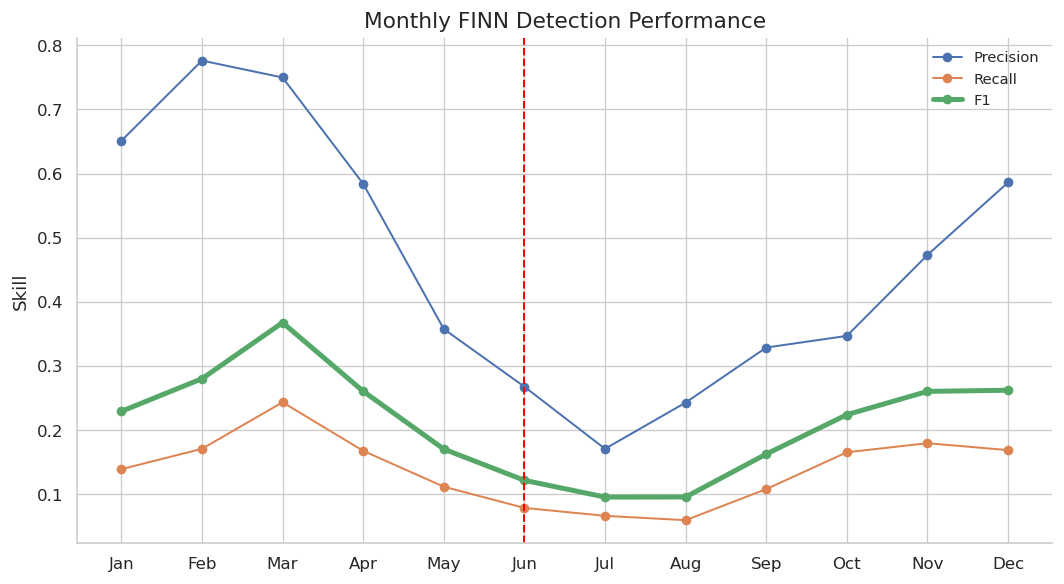

In [59]:
fig, ax = plt.subplots(
    figsize=(9,5)
)

ax.plot(
    monthly_skill["month"],
    monthly_skill["precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    monthly_skill["month"],
    monthly_skill["recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    monthly_skill["month"],
    monthly_skill["f1"],
    marker="o",
    linewidth=3,
    label="F1"
)

ax.axvline(
    6,
    color="red",
    ls="--"
)

ax.set_xticks(
    range(1,13)
)

ax.set_xticklabels(
    MONTHS_LABELS
)

ax.set_ylabel(
    "Skill"
)

ax.set_title(
    "Monthly FINN Detection Performance"
)

ax.legend()

plt.tight_layout()
plt.show()

In [60]:
tp = overall_metrics["TP"]

fp = overall_metrics["FP"]

fn = overall_metrics["FN"]

june_precision = tp/(tp+fp+1e-6)

june_recall = tp/(tp+fn+1e-6)

june_f1 = (
    2*june_precision*june_recall
    /
    (
        june_precision
        +
        june_recall
        +
        1e-6
    )
)

june_jaccard = (
    tp
    /
    (
        tp+fp+fn+1e-6
    )
)

june_dice = (
    2*tp
    /
    (
        2*tp+fp+fn+1e-6
    )
)

In [61]:
# annual confusion matrix
annual_metrics = run_daily_spatiotemporal_analysis(
    gdf_annual,
    finn_annual,
    lat,
    lon
)

In [62]:
tp = annual_metrics["TP"]

fp = annual_metrics["FP"]

fn = annual_metrics["FN"]

precision = tp/(tp+fp+1e-6)

recall = tp/(tp+fn+1e-6)

f1 = (
    2*precision*recall
    /
    (precision+recall+1e-6)
)

jaccard = (
    tp
    /
    (tp+fp+fn+1e-6)
)

dice = (
    2*tp
    /
    (
        2*tp+fp+fn+1e-6
    )
)

annual_detection_metrics = pd.Series({

    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "Jaccard":jaccard,
    "Dice":dice

})

display(
    annual_detection_metrics
)

Precision    0.559571
Recall       0.162487
F1           0.251844
Jaccard      0.144063
Dice         0.251844
dtype: float64

In [63]:
summary_table = pd.DataFrame({

    "Metric":[

        "Precision",
        "Recall",
        "F1",
        "Jaccard",
        "Dice"

    ],

    "June":[

        june_precision,
        june_recall,
        june_f1,
        june_jaccard,
        june_dice

    ],

    "Annual":[

        annual_detection_metrics["Precision"],
        annual_detection_metrics["Recall"],
        annual_detection_metrics["F1"],
        annual_detection_metrics["Jaccard"],
        annual_detection_metrics["Dice"]

    ]
})

summary_table

,Metric,June,Annual
0,Precision,0.267823,0.559571
1,Recall,0.078888,0.162487
2,F1,0.121876,0.251844
3,Jaccard,0.064893,0.144063
4,Dice,0.121876,0.251844


## Discussion

## Unknown

In [64]:
pm_pred = pd.DataFrame({

    "log_pm": np.linspace(
        fire_match_df["log_pm"].min(),
        fire_match_df["log_pm"].max(),
        200
    )

})

pm_pred["prob"] = pm_model_log.predict(
    pm_pred
)

pm_pred.head()

,log_pm,prob
0,-5.677781,0.010354
1,-5.636945,0.010560
2,-5.596109,0.010769
3,-5.555273,0.010982
4,-5.514437,0.011200


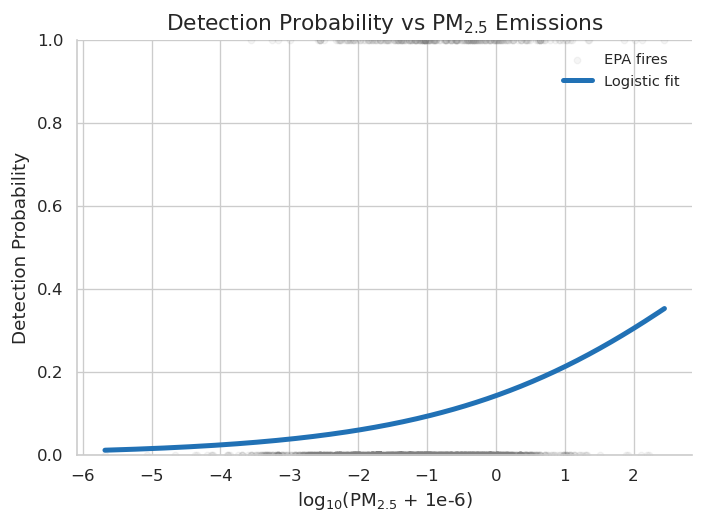

In [65]:
fig, ax = plt.subplots(
    figsize=(6,4.5)
)

ax.scatter(
    fire_match_df["log_pm"],
    fire_match_df["matched"],
    alpha=0.08,
    color="gray",
    s=15,
    label="EPA fires"
)

ax.plot(
    pm_pred["log_pm"],
    pm_pred["prob"],
    color="#2171b5",
    linewidth=3,
    label="Logistic fit"
)

ax.set_xlabel(
    r"log$_{10}$(PM$_{2.5}$ + 1e-6)"
)

ax.set_ylabel(
    "Detection Probability"
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Detection Probability vs PM$_{2.5}$ Emissions"
)

ax.legend()

sns.despine()

plt.tight_layout()

savefig(
    fig,
    "fig15a_logistic_pm25_detection.png"
)

plt.show()

For each 10-fold increase in PM2.5 emissions, 
the odds of FINN detection increase by1.63..

In [66]:
area_pred = pd.DataFrame({

    "log_area": np.linspace(
        fire_match_df["log_area"].min(),
        fire_match_df["log_area"].max(),
        200
    )

})

area_pred["prob"] = area_model_log.predict(
    area_pred
)

area_pred.head()

,log_area,prob
0,-4.382281,0.016785
1,-4.354978,0.017078
2,-4.327675,0.017376
3,-4.300372,0.017678
4,-4.273069,0.017987


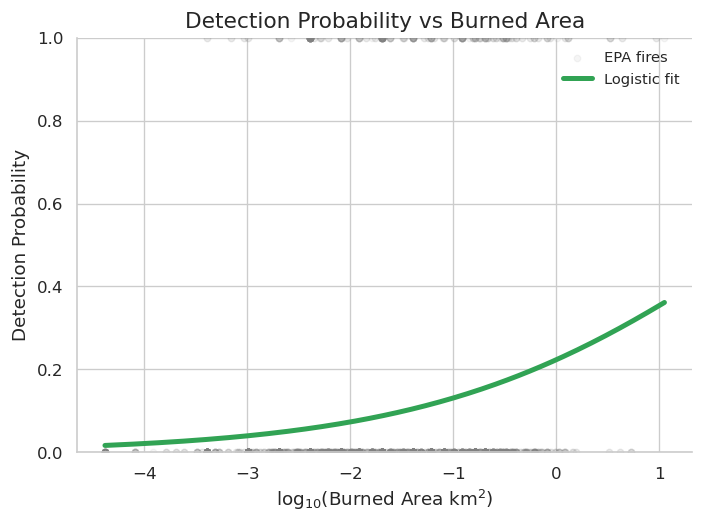

In [67]:
fig, ax = plt.subplots(
    figsize=(6,4.5)
)

ax.scatter(
    fire_match_df["log_area"],
    fire_match_df["matched"],
    alpha=0.08,
    color="gray",
    s=15,
    label="EPA fires"
)

ax.plot(
    area_pred["log_area"],
    area_pred["prob"],
    color="#31a354",
    linewidth=3,
    label="Logistic fit"
)

ax.set_xlabel(
    r"log$_{10}$(Burned Area km$^2$)"
)

ax.set_ylabel(
    "Detection Probability"
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Detection Probability vs Burned Area"
)

ax.legend()

sns.despine()

plt.tight_layout()

savefig(
    fig,
    "fig15b_logistic_area_detection.png"
)

plt.show()

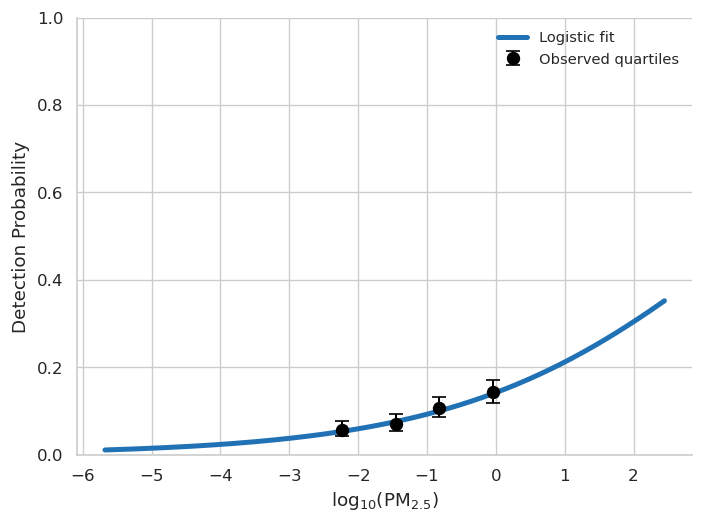

In [68]:
fig, ax = plt.subplots(
    figsize=(6,4.5)
)

ax.plot(
    pm_pred["log_pm"],
    pm_pred["prob"],
    color="#2171b5",
    linewidth=3,
    label="Logistic fit"
)

quartile_x = []

for q in ["Q1","Q2","Q3","Q4"]:

    x = np.median(
        fire_match_df.loc[
            fire_match_df["pm_bin"] == q,
            "log_pm"
        ]
    )

    quartile_x.append(x)

ax.errorbar(
    quartile_x,
    pm_summary["rate"],
    yerr=[
        pm_summary["rate"] - pm_summary["ci_low"],
        pm_summary["ci_high"] - pm_summary["rate"]
    ],
    fmt="o",
    color="black",
    markersize=7,
    capsize=4,
    label="Observed quartiles"
)

ax.set_xlabel(
    r"log$_{10}$(PM$_{2.5}$)"
)

ax.set_ylabel(
    "Detection Probability"
)

ax.set_ylim(0,1)

ax.legend()

sns.despine()

plt.tight_layout()

plt.show()

For each 10-fold increase in PM2.5 emissions, the odds of FINN detection increase by 1.9.

In [69]:
# --- EPA vs. FINN total PM2.5, Georgia, June 2022 ---
ga_pm_finn = apply_ga_mask(pm_tons.values, ga_mask)
finn_total_pm25 = np.nansum(ga_pm_finn)
epa_total_pm25 = gdf_june["pm2.5"].sum()

bias = finn_total_pm25 - epa_total_pm25
ratio = finn_total_pm25 / (epa_total_pm25 + 1e-6)

print(f"EPA total PM2.5 (June, GA)  : {epa_total_pm25:,.1f} tons")
print(f"FINN total PM2.5 (June, GA) : {finn_total_pm25:,.1f} tons")
print(f"Difference (FINN - EPA)     : {bias:,.1f} tons")
print(f"Ratio (FINN / EPA)          : {ratio:.2f}")

EPA total PM2.5 (June, GA)  : 2,674.7 tons
FINN total PM2.5 (June, GA) : 3,767.5 tons
Difference (FINN - EPA)     : 1,092.8 tons
Ratio (FINN / EPA)          : 1.41


In [70]:
june_grid = np.array(
    finn_annual["pm_tons"]
    .sel(time=finn_annual["time"].dt.month == 6)
    .sum(dim="time")
)

june_grid = apply_ga_mask(
    june_grid,
    ga_mask
)

# june_total_pm25 = pm_total.sum().values

# annual_total_pm25 = finn_annual["pm_total"].sum().values
june_total_pm25 = np.nansum(
    apply_ga_mask(
        pm_total.values,
        ga_mask
    )
)

annual_total_pm25 = np.nansum(
    apply_ga_mask(
        finn_annual["pm_total"].values,
        ga_mask
    )
)

print(f"June total: {june_total_pm25:,.0f} tons")
print(f"Annual total: {annual_total_pm25:,.0f} tons")

print(
    f"June contribution = "
    f"{100*june_total_pm25/annual_total_pm25:.1f}%"
)

June total: 3,768 tons
Annual total: 188,652 tons
June contribution = 2.0%


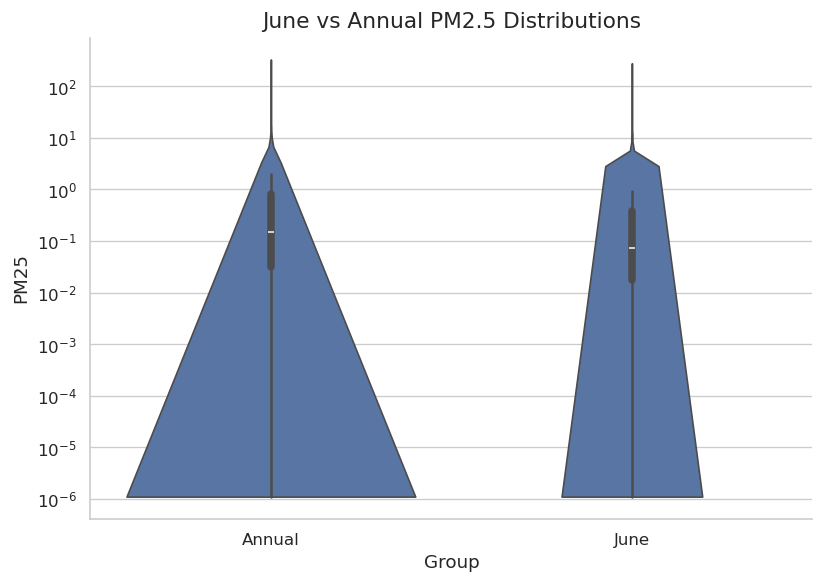

In [71]:
fig, ax = plt.subplots(
    figsize=(7,5)
)

plot_df = pd.concat([

    pd.DataFrame({
        "PM25":annual_pm,
        "Group":"Annual"
    }),

    pd.DataFrame({
        "PM25":june_pm,
        "Group":"June"
    })

])

sns.violinplot(
    data=plot_df,
    x="Group",
    y="PM25",
    cut=0
)

ax.set_yscale("log")

ax.set_title(
    "June vs Annual PM2.5 Distributions"
)

plt.tight_layout()

In [72]:
tp = overall_metrics["TP"]
fp = overall_metrics["FP"]
fn = overall_metrics["FN"]

precision = tp/(tp+fp)

recall = tp/(tp+fn)

f1 = (
    2*precision*recall
    /
    (precision+recall)
)

jaccard = (
    tp
    /
    (tp+fp+fn)
)

dice = (
    2*tp
    /
    (2*tp+fp+fn)
)

pd.Series({
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "Jaccard":jaccard,
    "Dice":dice
})

Precision    0.267823
Recall       0.078888
F1           0.121876
Jaccard      0.064893
Dice         0.121876
dtype: float64

### limitations and future work

NameError: name 'daily_stats' is not defined

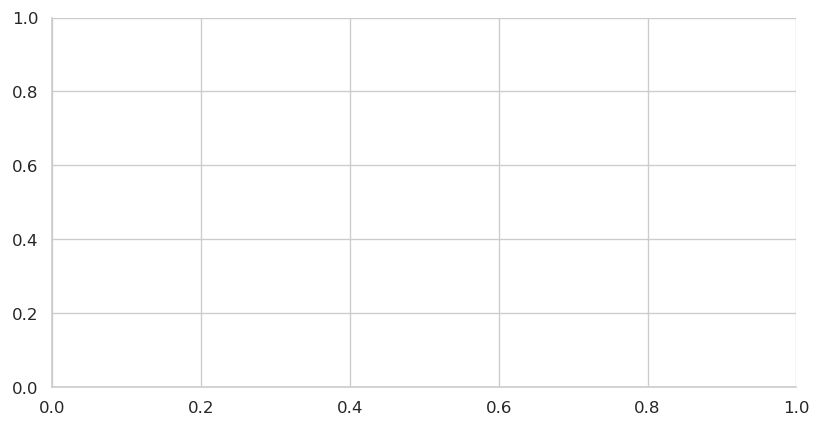

In [75]:
fig, ax1 = plt.subplots(figsize=(8,4))

# EPA
ax1.plot(
    daily_stats['date'],
    daily_stats['epa_fires'],
    color='black',
    linewidth=2,
    label='EPA fires'
)

ax1.set_ylabel('EPA fires per day', color='black')
ax1.tick_params(axis='y', colors='black')

# FINN
ax2 = ax1.twinx()

ax2.plot(
    daily_stats['date'],
    daily_stats['finn_active_cells'],
    color='firebrick',
    linewidth=2,
    label='FINN active cells'
)

ax2.set_ylabel('FINN active cells per day', color='firebrick')
ax2.tick_params(axis='y', colors='firebrick')

plt.title('Daily Fire Activity: EPA vs FINN')
ax1.set_xlabel('Date')

fig.autofmt_xdate()
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
daily_confusion["daily_fires"] = (
    daily_confusion["TP"] +
    daily_confusion["FN"]
)

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
    daily_confusion["date"],
    daily_confusion["daily_fires"],
    color="black",
    linewidth=2,
    label="EPA Fires"
)

ax.plot(
    daily_confusion["date"],
    daily_confusion["TP"],
    color="#2ca25f",
    linewidth=2,
    label="Detected by FINN"
)

ax.set_ylabel("Fire Count")

ax.legend()

ax.set_title(
    "Daily EPA Fires and FINN Detections"
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
daily_confusion["Detected"] = daily_confusion["TP"]
daily_confusion["Missed"] = daily_confusion["FN"]

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(
    daily_confusion["date"],
    daily_confusion["Detected"],
    color="#3182bd",
    label="Detected"
)

ax.bar(
    daily_confusion["date"],
    daily_confusion["Missed"],
    bottom=daily_confusion["Detected"],
    color="#d9d9d9",
    label="Missed"
)

ax.set_ylabel("EPA Fires")

ax.set_title(
    "Daily EPA Fires Detected and Missed by FINN"
)

ax.legend()

fig.autofmt_xdate()

plt.tight_layout()
plt.show()